# 3.8 Lead-lag, with the reactivity filter applied

Here we follow directly from `3.7`, the tuned session-level model. This notebook runs the
project's lead-lag test: does sentiment predict a session's return or react to it 
split by whether an article is explicitly reactive, to test the hypothesis that the
project's already-established finding (sentiment tracks the *previous* session's
return, not the next one) is disproportionately carried by articles that restate a
price move rather than comment on one.

**What changed in the package for this notebook:** `news_sentiment/text/reactive.py`
only, the same `classify_reactive_sentence()` from the sentence-level work is unchanged.
`news_sentiment/text/sentiment.py` is untouched; the entity-scoped, corpus-pipeline
version of reactivity (`aggregate_reactive_features()`, wired into
`build_model_features()`) lives on the other branch and stays there.

### 0. Setup

Real headline and body text for all four tickers (`{TICKER}_processed_no_raw.parquet`),
merged onto the real, current `model_ready_pooled.parquet` by `(article_id, ticker)`.

In [1]:
import re
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

from news_sentiment.config import FIGURES_DIR, PROCESSED_DATA_DIR
from news_sentiment.text.reactive import classify_reactive_sentence

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

df = pd.read_parquet(PROCESSED_DATA_DIR / "merged" / "model_ready_pooled.parquet")
df = df.sort_values("timestamp_utc").reset_index(drop=True)

texts = []
for ticker in ["AAPL", "AMZN", "NVDA", "TSLA"]:
    t = pd.read_parquet(PROCESSED_DATA_DIR / f"{ticker}_processed_no_raw.parquet")
    t = t[["article_id", "headline", "processed_body"]].copy()
    t["ticker"] = ticker
    texts.append(t)
texts = pd.concat(texts, ignore_index=True)

df = df.merge(texts, on=["article_id", "ticker"], how="left")
print(f"pooled: {df.shape}, missing headline after merge: {df['headline'].isna().sum()}")

2026-08-30 20:35:57.012 | INFO     | news_sentiment.config:<module>:12 - PROJ_ROOT path is: C:\Users\kacpe\OneDrive - University of Warwick\PROJECTS\Stock Predictor\stock-predictor


pooled: (41298, 39), missing headline after merge: 0


### 1. Reactivity scoring

**`reactive_headline`**: `classify_reactive_sentence()` applied directly to the real
headline. Real, exact, no proxy involved.

**Body reactivity: a proxy, and the scope limitation stated plainly.** The full pipeline's
`aggregate_reactive_features()` scores only *target-mention* sentences, so a reactive
sentence about a different company mentioned in passing doesn't count. That scoping
needs `entity_filter.process_articles()` - spaCy sentence splitting plus coreference
resolution - which is something which we will not run here. What runs here instead 
is a lightweight regex sentence splitter (no spaCy) over
the real `processed_body` text, scored the same way, aggregated per article. It is real
body text, not a summary-based stand-in, but it is **whole-article, not entity-scoped**:
a reactive sentence about a different company anywhere in the article counts toward this
article's reactivity. That is a real limitation, not a rounding error, and it is revisited
in section 5.

In [2]:
def naive_split(text):
    if not isinstance(text, str) or not text.strip():
        return []
    parts = re.split(r'(?<=[.!?])\s+(?=[A-Z("])', text.strip())
    return [p.strip() for p in parts if len(p.strip()) >= 20]


df["reactive_headline"] = df["headline"].apply(
    lambda h: classify_reactive_sentence(h).score if isinstance(h, str) else np.nan
)
print(f"reactive_headline >= 1.0: {(df['reactive_headline'] >= 1.0).mean():.1%} of articles")

t0 = time.time()
unique_bodies = df[["article_id", "processed_body"]].drop_duplicates(subset="article_id")
body_scores = {}
for aid, body in zip(unique_bodies["article_id"], unique_bodies["processed_body"]):
    sents = naive_split(body)
    if not sents:
        body_scores[aid] = (0, np.nan, np.nan, np.nan)
        continue
    scores = [classify_reactive_sentence(s).score for s in sents]
    is_r = [s >= 1.0 for s in scores]
    body_scores[aid] = (sum(is_r), sum(is_r) / len(sents), float(np.mean(scores)), float(np.max(scores)))
print(f"body-proxy scoring: {len(unique_bodies)} articles in {time.time()-t0:.0f}s")

body_df = pd.DataFrame.from_dict(
    body_scores, orient="index",
    columns=["n_reactive_sents", "reactive_share", "reactive_mean", "reactive_max"],
).rename_axis("article_id").reset_index()
df = df.merge(body_df, on="article_id", how="left")
print(df["reactive_share"].describe().round(4).to_string())

reactive_headline >= 1.0: 6.3% of articles


body-proxy scoring: 35678 articles in 77s
count    41298.0000
mean         0.0380
std          0.0585
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0600
max          1.0000


We use the following **thresholds**: `reactive_headline >= 1.0`
(the existing default) or `reactive_share >= 0.5` (a majority of body sentences
reactive) marks an article reactive.

In [3]:
REACTIVE_HEADLINE_THRESHOLD = 1.0
REACTIVE_SHARE_THRESHOLD = 0.5

df["is_reactive_article"] = (
    (df["reactive_headline"] >= REACTIVE_HEADLINE_THRESHOLD)
    | (df["reactive_share"].fillna(0) >= REACTIVE_SHARE_THRESHOLD)
)
print(f"reactive articles: {df['is_reactive_article'].sum()} of {len(df)} "
      f"({df['is_reactive_article'].mean():.1%})")

reactive articles: 2597 of 41298 (6.3%)


### 2. Baseline lead-lag

For each ticker, we line sessions up
chronologically and correlate that session's sentiment against the abnormal return of
sessions before it, the same session, and sessions after it.

In [4]:
LAGS = range(-5, 6)


def lag_curve(article_df, label):
    sessions_v = article_df.groupby(["session_open", "ticker"], observed=True).agg(
        abnormal_return_1d=("abnormal_return_1d", "first"),
        fus_sentiment_mean=("fus_conf_graft_floor_mean", "mean"),
    ).reset_index()
    rows = []
    for lag in LAGS:
        s_all, r_all = [], []
        for ticker, sub in sessions_v.groupby("ticker"):
            sub = sub.sort_values("session_open").reset_index(drop=True)
            shifted_return = sub["abnormal_return_1d"].shift(-lag)
            valid = sub["fus_sentiment_mean"].notna() & shifted_return.notna()
            s_all.append(sub["fus_sentiment_mean"][valid])
            r_all.append(shifted_return[valid])
        s_all, r_all = pd.concat(s_all), pd.concat(r_all)
        r, p = (np.nan, np.nan) if len(s_all) < 10 else pearsonr(s_all, r_all)
        rows.append({"variant": label, "lag": lag, "n": len(s_all), "r": r, "p": p})
    print(f"{label}: {len(sessions_v)} session-ticker rows from {len(article_df)} articles")
    return pd.DataFrame(rows)


baseline_curve = lag_curve(df, "baseline (all)")
print()
print(baseline_curve.round(4).to_string(index=False))

baseline (all): 924 session-ticker rows from 41298 articles

       variant  lag   n       r      p
baseline (all)   -5 904  0.0278 0.4037
baseline (all)   -4 908  0.0346 0.2977
baseline (all)   -3 912  0.1085 0.0010
baseline (all)   -2 916  0.1168 0.0004
baseline (all)   -1 920  0.3285 0.0000
baseline (all)    0 924  0.0732 0.0261
baseline (all)    1 920 -0.0224 0.4975
baseline (all)    2 916 -0.0663 0.0450
baseline (all)    3 912 -0.0991 0.0027
baseline (all)    4 908 -0.0068 0.8371
baseline (all)    5 904 -0.0356 0.2853


We get the following: `lag = -1` (sentiment against the
*previous* session's return) is the strongest correlation in the table, and every
positive (predictive) lag sits at or near zero.

### 3. The reactivity-filtered split

Three session-level sentiment series, same lag sweep: **baseline** (all articles,
section 2 again, for a direct comparison), **reactive excluded**, **reactive only**.

In [5]:
variants = {
    "baseline (all)": df,
    "reactive excluded": df[~df["is_reactive_article"]],
    "reactive only": df[df["is_reactive_article"]],
}
curves = pd.concat([lag_curve(sub, name) for name, sub in variants.items()], ignore_index=True)
print()
print(curves.pivot(index="lag", columns="variant", values="r").round(4).to_string())
print()
print("lag = -1 detail:")
print(curves[curves.lag == -1][["variant", "n", "r", "p"]].to_string(index=False))

baseline (all): 924 session-ticker rows from 41298 articles


reactive excluded: 924 session-ticker rows from 38701 articles
reactive only: 761 session-ticker rows from 2597 articles

variant  baseline (all)  reactive excluded  reactive only
lag                                                      
-5               0.0278             0.0309         0.0341
-4               0.0346             0.0373         0.0316
-3               0.1085             0.1110         0.0106
-2               0.1168             0.1143         0.0531
-1               0.3285             0.2860         0.2861
 0               0.0732             0.0599         0.0894
 1              -0.0224            -0.0203         0.0114
 2              -0.0663            -0.0570        -0.0708
 3              -0.0991            -0.1000        -0.0041
 4              -0.0068            -0.0140        -0.0286
 5              -0.0356            -0.0375         0.0218

lag = -1 detail:
          variant   n        r            p
   baseline (all) 920 0.328471 1.385017e-24
reactive excluded

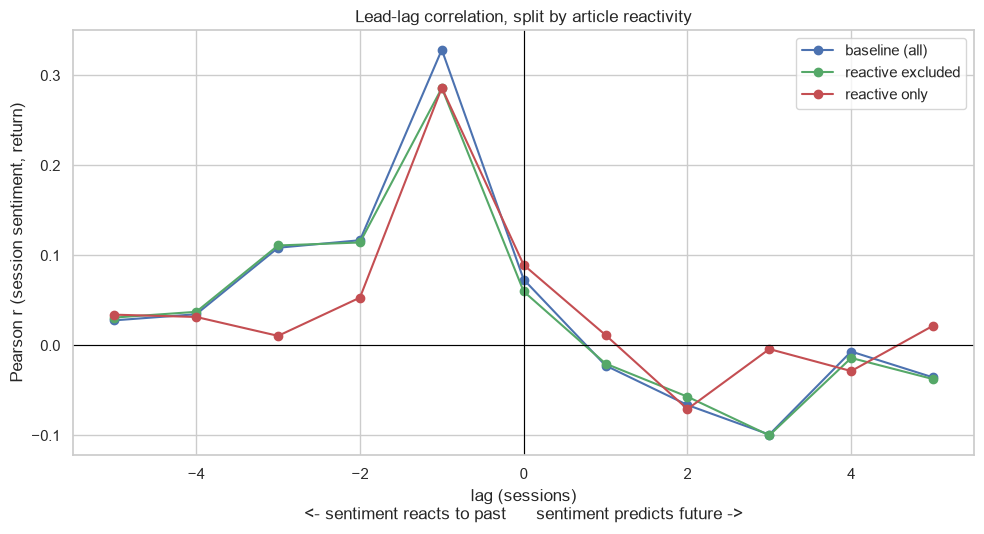

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for variant, color in zip(variants, ["#4C72B0", "#55A868", "#C44E52"]):
    sub = curves[curves.variant == variant].sort_values("lag")
    ax.plot(sub["lag"], sub["r"], marker="o", label=variant, color=color)
ax.axvline(0, color="black", linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("lag (sessions)\n<- sentiment reacts to past      sentiment predicts future ->")
ax.set_ylabel("Pearson r (session sentiment, return)")
ax.set_title("Lead-lag correlation, split by article reactivity")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "3.8-leadlag-reactivity-split.png", dpi=120)
plt.show()

### 4. Reading the results

**The hypothesis was that reactive articles disproportionately carry the `lag = -1`
correlation, so excluding them should weaken it and the reactive-only subset should show
it concentrated.** That is not what happened. `reactive excluded` (r = 0.286) and
`reactive only` (r = 0.286) land on **the same number**, both below the `baseline`
figure of 0.328. Reactive articles are not uniquely responsible for the backward-looking
pattern -- it is broad-based, present in both the 93.7% of articles that never trip a
reactive pattern and the 6.3% that do, at essentially the same strength.

However this could also imply that our reactivity filter is not strong enough, i.e. we have too many false negatives slipping through which means that our filter is essentially redundant.

**What the baseline vs either subset gap does suggest.** Both subsets sit below the full
population's correlation, which is the signature of the excluded 6% contributing
something to the full aggregate beyond their raw count, consistent with, though not
proof of, the reactive articles carrying more extreme sentiment on average (checked
directly below). Removing a small, more extreme scoring group can lower a correlation
computed over everyone else even when that group isn't privately driving the
relationship, simply by removing variance the full-sample number was drawing on.

We can read this as an indicator that the `lag=1` result is maybe not explained by just reactive articles, however it is covered more broadly. Despite this, we also cannot rule out the situation that the reactivity filter needs to be improved.

In [7]:
df["abs_sentiment"] = df["fus_conf_graft_floor_mean"].abs()
print(df.groupby("is_reactive_article")["abs_sentiment"].describe().round(4).to_string())

                       count    mean     std  min     25%     50%     75%     max
is_reactive_article                                                              
False                38701.0  0.1211  0.1047  0.0  0.0295  0.1068  0.1768  0.6433
True                  2597.0  0.1429  0.1055  0.0  0.0568  0.1330  0.1959  0.5465


**The magnitude check is directionally consistent, not dramatic.** Reactive
articles average |sentiment| 0.143 against non-reactive articles' 0.121 - higher, as
the "loud articles get flagged reactive" intuition would predict, but not by enough on
its own to fully account for the baseline vs subset gap in section 3. Both pieces
together (a real but modest magnitude difference, and two subset correlations that land
on the same number) point the same way: reactivity as scored here is a weak, partial
proxy for whatever is actually driving the backward-looking relationship, not a clean
standin for it.

### 5. What this does and doesn't settle

**Settled, on real data, at full corpus scale:** filtering by whole-article reactivity does not isolate the mechanism behind the project's
lead-lag finding. The reactive and non-reactive subsets behave the same way at `lag =
-1`, and both differ from the full population number in a way better explained by a
modest magnitude effect than by the reactive subset privately carrying the relationship.

**Not settled, because of the proxy's known scope limit.** Section 1 flagged this in
advance: the body reactivity signal here is whole article, not entity scoped, so an
article that mentions a rival's price move alongside genuine coverage of the target gets
the same "reactive" flag as one that is entirely about the target's own move. We can fix this by running the full scoring pipeline again, however we need to decide whether this is even worth the extra heavy computation time.

**Recommendation.** This result is not a reason to abandon the reactivity feature yet, and it
is not a reason to run the full corpus-scale pipeline either - it is a reason to treat
that decision as still open, exactly as it was going in. What it does rule out is finding
a shortcut: the fast, spaCy-free proxy tested here is fast enough to have been worth
trying, and it came back genuinely uninformative about the mechanism rather than merely
noisy, which is itself the useful result of running it.